### **Download and load the dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Download dataset from Kaggle
!wget -q https://www.kaggle.com/api/v1/datasets/download/shwetabh123/mall-customers -O mall_customers.zip

# Extract dataset
!unzip -o mall_customers.zip

# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Display first 5 rows
df.head()

Archive:  mall_customers.zip
  inflating: Mall_Customers.csv      


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### **Check the dataset**

In [ ]:
# Check dataset information
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
df.describe()

Dataset Shape: (200, 5)

Column Names:
['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Missing Values:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Statistical Summary:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### **Create spending categories**

In [ ]:
# Create spending categories from Spending Score

def spending_category(score):
    if score <= 33:
        return "Low"
    elif score <= 66:
        return "Medium"
    else:
        return "High"

df["Spending_Category"] = df["Spending Score (1-100)"].apply(spending_category)

# Display the first 10 rows
df[["Age", "Annual Income (k$)", "Spending Score (1-100)", "Spending_Category"]].head(10)

# Check number of customers in each category
print("\nCategory Distribution:")
print(df["Spending_Category"].value_counts())


Category Distribution:
Spending_Category
Medium    94
High      57
Low       49
Name: count, dtype: int64


### **Select features and split the data**

In [ ]:
from sklearn.model_selection import train_test_split

# Features
X = df[["Age", "Annual Income (k$)"]]

# Target
y = df["Spending_Category"]

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining category distribution:")
print(y_train.value_counts())

print("\nTesting category distribution:")
print(y_test.value_counts())

Training samples: 160
Testing samples: 40

Training category distribution:
Spending_Category
Medium    75
High      46
Low       39
Name: count, dtype: int64

Testing category distribution:
Spending_Category
Medium    19
High      11
Low       10
Name: count, dtype: int64


### **Feature Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit only on training data and transform both datasets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("First 5 scaled training samples:")
print(X_train_scaled[:5])

print("\nScaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

First 5 scaled training samples:
[[ 1.14091455 -1.31167126]
 [ 0.70402665 -0.8836087 ]
 [ 1.57780245 -1.2338417 ]
 [-0.5338224  -0.8836087 ]
 [-1.04352495 -0.8836087 ]]

Scaled training shape: (160, 2)
Scaled testing shape: (40, 2)


### **Train the first KNN model (K = 5)**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Initialize KNN model
knn = KNeighborsClassifier(
    n_neighbors=5,
    metric="euclidean"
)

# Train the model
knn.fit(X_train_scaled, y_train)

# Predict on test data
y_pred = knn.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("KNN Model with K = 5")
print("Distance Metric: Euclidean")
print(f"Accuracy: {accuracy * 100:.2f}%")

KNN Model with K = 5
Distance Metric: Euclidean
Accuracy: 80.00%


### **Train KNN for different K values**

In [ ]:
# Test different values of K
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric="euclidean"
    )

    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

# Print accuracy for each K
for k, accuracy in zip(k_values, accuracies):
    print(f"K = {k:2d} --> Accuracy = {accuracy * 100:.2f}%")

# Find best K
best_index = np.argmax(accuracies)
best_k = list(k_values)[best_index]
best_accuracy = accuracies[best_index]

print("\nBest K:", best_k)
print(f"Best Accuracy: {best_accuracy * 100:.2f}%")

K =  1 --> Accuracy = 75.00%
K =  2 --> Accuracy = 77.50%
K =  3 --> Accuracy = 80.00%
K =  4 --> Accuracy = 80.00%
K =  5 --> Accuracy = 80.00%
K =  6 --> Accuracy = 77.50%
K =  7 --> Accuracy = 80.00%
K =  8 --> Accuracy = 77.50%
K =  9 --> Accuracy = 75.00%
K = 10 --> Accuracy = 80.00%
K = 11 --> Accuracy = 80.00%
K = 12 --> Accuracy = 75.00%
K = 13 --> Accuracy = 77.50%
K = 14 --> Accuracy = 72.50%
K = 15 --> Accuracy = 72.50%
K = 16 --> Accuracy = 75.00%
K = 17 --> Accuracy = 72.50%
K = 18 --> Accuracy = 77.50%
K = 19 --> Accuracy = 70.00%
K = 20 --> Accuracy = 70.00%

Best K: 3
Best Accuracy: 80.00%


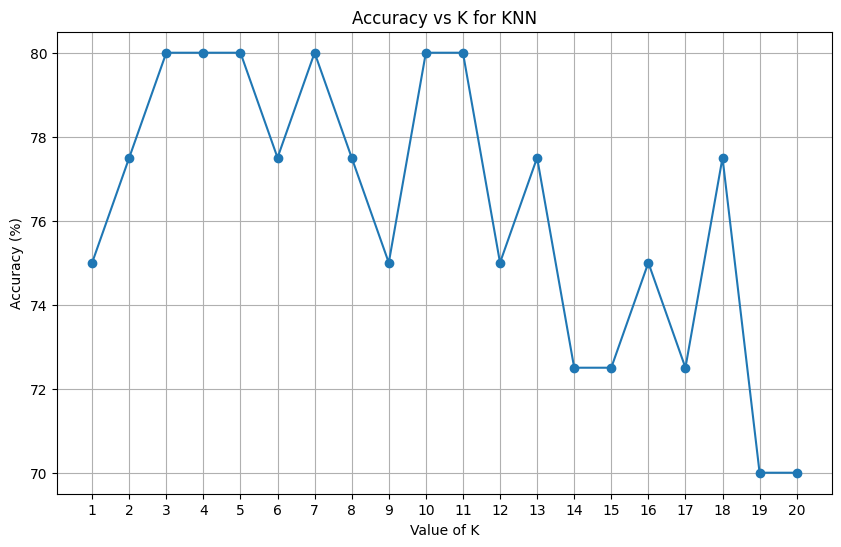

In [ ]:
# Plot Accuracy vs K

plt.figure(figsize=(10, 6))

plt.plot(
    list(k_values),
    [a * 100 for a in accuracies],
    marker='o'
)

plt.xlabel("Value of K")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs K for KNN")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()


### **Compare Euclidean, Manhattan and Chebyshev**

In [ ]:
# Compare different distance metrics

metrics = ["euclidean", "manhattan", "chebyshev"]
metric_accuracies = {}

for metric in metrics:
    knn = KNeighborsClassifier(
        n_neighbors=5,
        metric=metric
    )

    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    metric_accuracies[metric] = accuracy

    print(f"{metric.capitalize():10s} --> Accuracy = {accuracy * 100:.2f}%")

Euclidean  --> Accuracy = 80.00%
Manhattan  --> Accuracy = 80.00%
Chebyshev  --> Accuracy = 82.50%


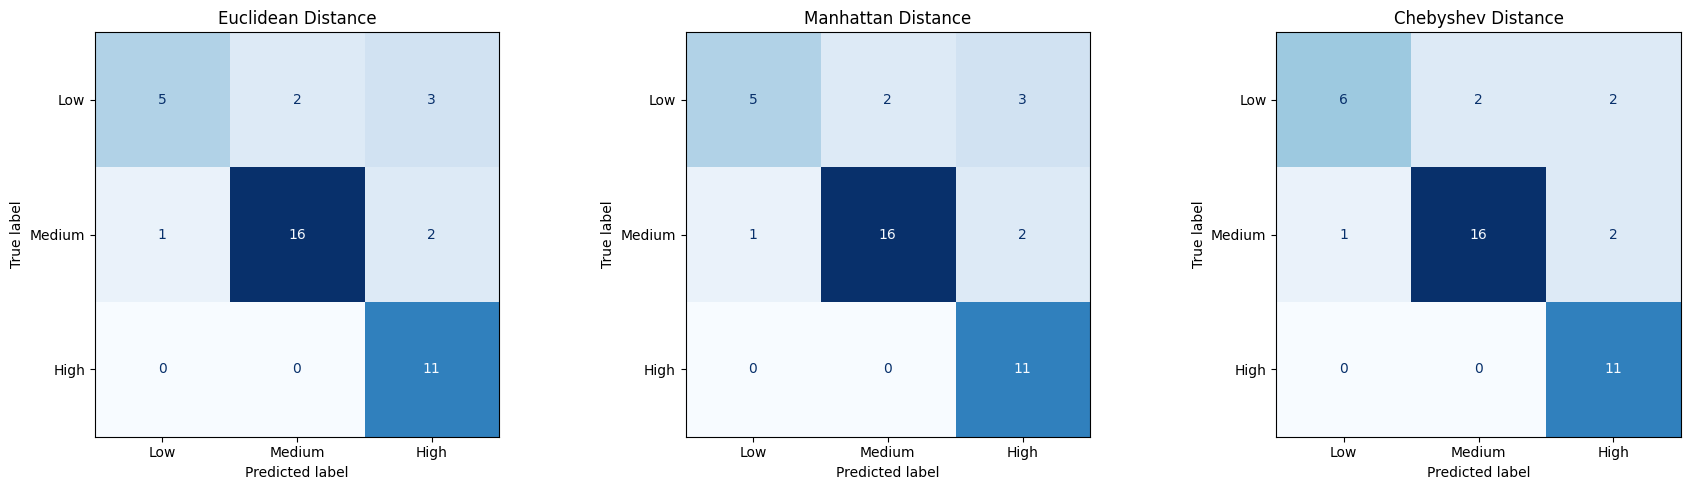

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Store predictions for each metric
metric_predictions = {}

for metric in metrics:
    knn = KNeighborsClassifier(
        n_neighbors=5,
        metric=metric
    )

    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)

    metric_predictions[metric] = y_pred

# Generate confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, metrics):
    cm = confusion_matrix(
        y_test,
        metric_predictions[metric],
        labels=["Low", "Medium", "High"]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Low", "Medium", "High"]
    )

    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{metric.capitalize()} Distance")

plt.tight_layout()
plt.show()

### **Decision boundaries for all three distance metrics**

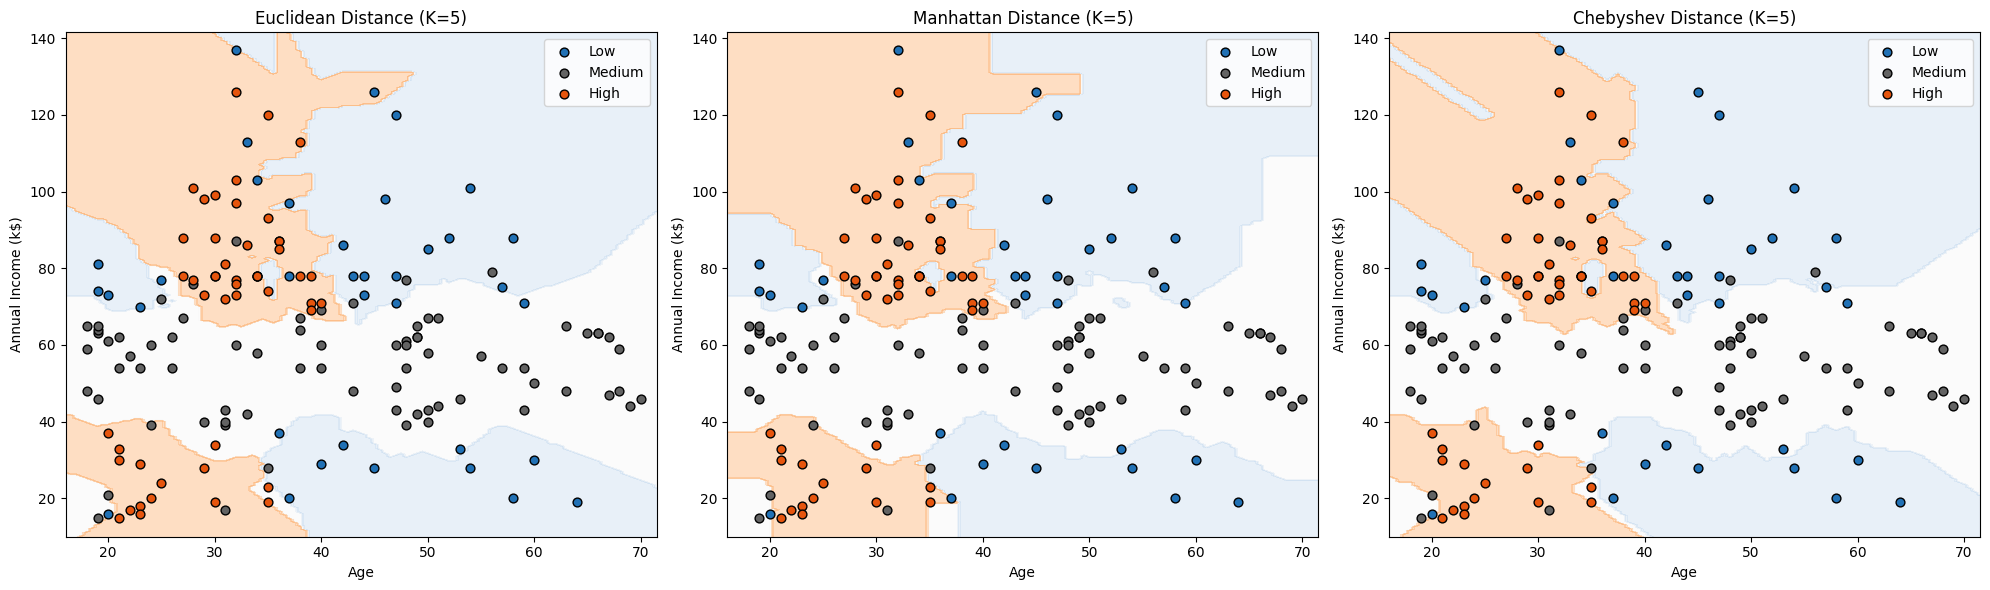

In [ ]:
from matplotlib.colors import ListedColormap

# Convert target labels to numerical values
class_mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

y_train_num = y_train.map(class_mapping)

# Create mesh grid using original feature values
x_min = X["Age"].min() - 2
x_max = X["Age"].max() + 2
y_min = X["Annual Income (k$)"].min() - 5
y_max = X["Annual Income (k$)"].max() + 5

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.5),
    np.arange(y_min, y_max, 0.5)
)

# Convert grid to DataFrame
grid = pd.DataFrame({
    "Age": xx.ravel(),
    "Annual Income (k$)": yy.ravel()
})

# Scale grid using the same scaler
grid_scaled = scaler.transform(grid)

# Background colors for Low, Medium, High
cmap_background = ListedColormap([
    "#c6dbef",
    "#f7f7f7",
    "#fdae6b"
])

# Point colors
point_colors = {
    "Low": "#2171b5",
    "Medium": "#636363",
    "High": "#e6550d"
}

# Create three plots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, metric in zip(axes, metrics):

    # Train KNN
    knn = KNeighborsClassifier(
        n_neighbors=5,
        metric=metric
    )

    knn.fit(X_train_scaled, y_train_num)

    # Predict every point in the grid
    Z = knn.predict(grid_scaled)
    Z = Z.reshape(xx.shape)

    # Plot decision regions
    ax.contourf(
        xx,
        yy,
        Z,
        alpha=0.4,
        cmap=cmap_background
    )

    # Plot training points
    for label, value in class_mapping.items():

        mask = y_train == label

        ax.scatter(
            X_train.loc[mask, "Age"],
            X_train.loc[mask, "Annual Income (k$)"],
            color=point_colors[label],
            label=label,
            edgecolor="black",
            s=40
        )

    ax.set_title(f"{metric.capitalize()} Distance (K=5)")
    ax.set_xlabel("Age")
    ax.set_ylabel("Annual Income (k$)")
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Create a comparison table for distance metrics

metric_results = pd.DataFrame({
    "Distance Metric": [
        "Euclidean",
        "Manhattan",
        "Chebyshev"
    ],
    "Accuracy (%)": [
        metric_accuracies["euclidean"] * 100,
        metric_accuracies["manhattan"] * 100,
        metric_accuracies["chebyshev"] * 100
    ]
})

print(metric_results)

  Distance Metric  Accuracy (%)
0       Euclidean          80.0
1       Manhattan          80.0
2       Chebyshev          82.5
